
Part A - Gini Verification
  y = [0, 0, 0, 1]
  Gini (computed) : 0.3750
  Gini (manual)   : 0.3750
  Best Feature     : 2
  Threshold        : 2.4500
  Information Gain : 0.4988
  Best Feature     : 2
  Threshold        : 2.4500
  Information Gain : 0.4988

Cardinality Bias Analysis
  Original best feature    : 2
  Augmented best feature   : 2
Original feature still wins, bias not dominant here.


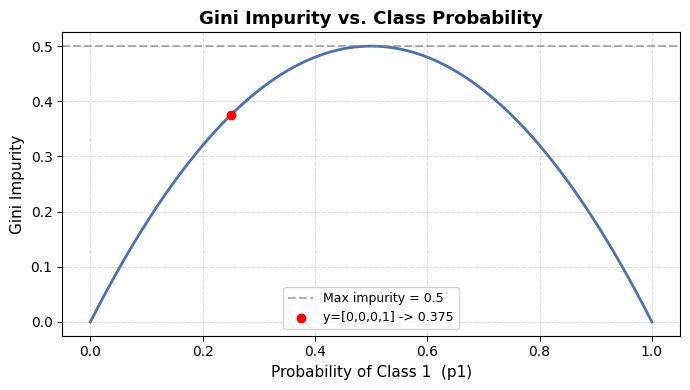

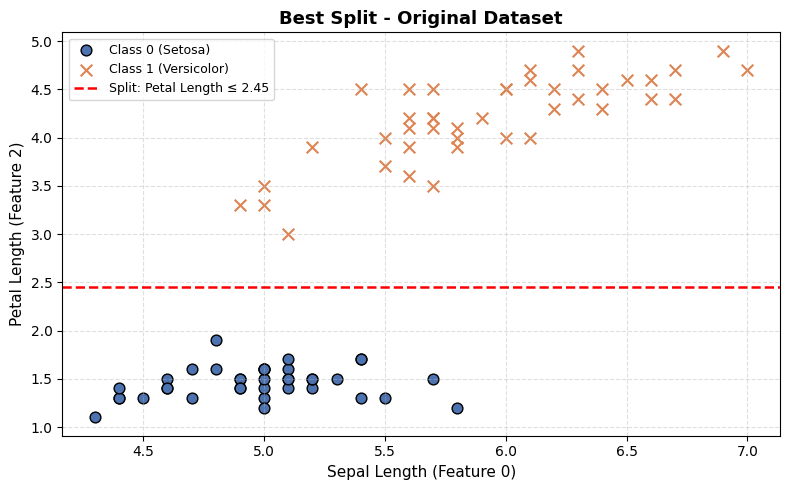

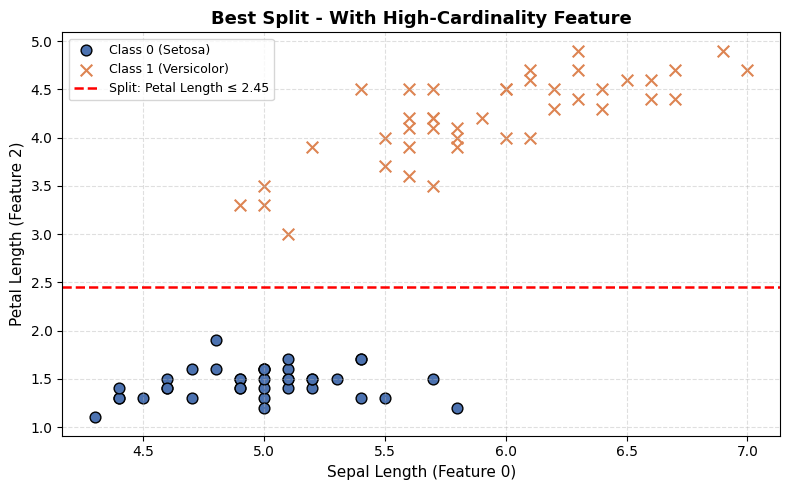

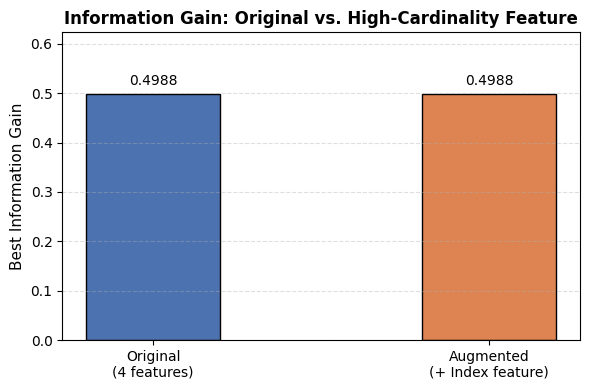

In [9]:
"""
Lab 6 Starter Code
Decision Tree Split using Gini and Information Gain
"""

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split


# ============================================================
# DATASET
# ============================================================

def load_binary_iris():
    """
    Load iris dataset but keep only two classes.

    This simplifies the task to binary classification
    so that Gini impurity is easier to compute.

    Returns
    -------
    X_train, X_test, y_train, y_test
    """
    data = load_iris()
    X = data.data
    y = data.target

    mask = y < 2
    X = X[mask]
    y = y[mask]

    return train_test_split(X, y, test_size=0.2, random_state=42)

# ============================================================
# STUDENT TASKS
# ============================================================


# ============================================================
# PART A: GINI IMPURITY
# ============================================================

def gini(y):
    """
    TODO

    Compute Gini impurity.

    Parameters
    ----------
    y : array-like

    Returns
    -------
    float
    """
    y = np.array(y)
    n = len(y)

    if n == 0:
        return 0.0

    # Compute class probabilities
    classes = np.unique(y)
    impurity = 1.0

    for c in classes:
        p = np.sum(y == c) / n
        impurity -= p ** 2

    return impurity


# ============================================================
# PART B: INFORMATION GAIN
# ============================================================

def information_gain(parent, left, right):
    """
    TODO

    Compute Information Gain.

    Parameters
    ----------
    parent : labels before split
    left : labels in left child
    right : labels in right child

    Returns
    -------
    float
    """
    parent = np.array(parent)
    left   = np.array(left)
    right  = np.array(right)

    n  = len(parent)
    nL = len(left)
    nR = len(right)

    # Weighted average of child impurities
    weighted_child = (nL / n) * gini(left) + (nR / n) * gini(right)

    return gini(parent) - weighted_child


# ============================================================
# PART C: FIND BEST SPLIT
# ============================================================

def find_best_split(X, y):
    """
    TODO

    Implement decision tree split search.

    Steps
    -----
    1. Loop over features
    2. Generate candidate thresholds
    3. Split dataset
    4. Compute information gain
    5. Track best split

    Returns
    -------
    best_feature
    best_threshold
    best_gain
    """
    
    y = np.array(y)
    n_features = X.shape[1]

    best_feature   = None
    best_threshold = None
    best_gain      = -np.inf

    for feature in range(n_features):
        thresholds = candidate_thresholds(X[:, feature])

        for threshold in thresholds:
            _, _, y_left, y_right = split_dataset(X, y, feature, threshold)

            # Skip empty splits
            if len(y_left) == 0 or len(y_right) == 0:
                continue

            gain = information_gain(y, y_left, y_right)

            if gain > best_gain:
                best_gain      = gain
                best_feature   = feature
                best_threshold = threshold

    return best_feature, best_threshold, best_gain


# ============================================================
# HELPER FUNCTIONS (provided)
# ============================================================

def split_dataset(X, y, feature, threshold):
    """
    Split dataset into left and right partitions.

    All samples with feature value <= threshold
    go to the left node.

    Returns
    -------
    X_left, X_right, y_left, y_right
    """
    mask = X[:, feature] <= threshold
    return X[mask], X[~mask], y[mask], y[~mask]


def candidate_thresholds(values):
    """
    Compute candidate thresholds for a feature.

    Thresholds are chosen as midpoints between
    consecutive sorted unique values.

    This mirrors the approach used in most
    decision tree implementations.
    """
    
    values = np.sort(np.unique(values))
    return (values[:-1] + values[1:]) / 2


def add_high_cardinality_feature(X):
    """
    Add deterministic high-cardinality feature.

    Each sample receives a unique value derived
    from its index.

    This allows us to observe the bias of
    decision trees toward features with many
    unique values.
    """
    
    N = len(X)
    index_feature = (np.arange(N) / N).reshape(-1, 1)
    return np.hstack([X, index_feature])


# ============================================================
# EXPERIMENT
# ============================================================

def run_split_experiment(X, y):
    feature, threshold, gain = find_best_split(X, y)
    print(f"  Best Feature     : {feature}")
    print(f"  Threshold        : {threshold:.4f}")
    print(f"  Information Gain : {gain:.4f}")
    return feature, threshold, gain


# ============================================================
# PART A VERIFICATION
# ============================================================

def verify_gini():
    y_test = [0, 0, 0, 1]
    result = gini(y_test)
    # Manual: p0=3/4, p1=1/4 → 1 - (9/16 + 1/16) = 1 - 10/16 = 6/16 = 0.375
    print(f"\nPart A - Gini Verification")
    print(f"  y = {y_test}")
    print(f"  Gini (computed) : {result:.4f}")
    print(f"  Gini (manual)   : 0.3750")
    assert abs(result - 0.375) < 1e-6, "Gini mismatch!"


# ============================================================
# PLOTS
# ============================================================

def plot_split(X, y, feature, threshold, title):
    """Scatter plot of feature 0 vs feature 2 with decision boundary."""
    feature_names = ["Sepal Length", "Sepal Width", "Petal Length", "Petal Width"]

    fig, ax = plt.subplots(figsize=(8, 5))

    ax.scatter(X[y == 0, 0], X[y == 0, 2], label="Class 0 (Setosa)",    marker="o", color="#4C72B0", edgecolors="k", s=60)
    ax.scatter(X[y == 1, 0], X[y == 1, 2], label="Class 1 (Versicolor)", marker="x", color="#DD8452", s=70, linewidths=1.5)

    if feature == 0:
        ax.axvline(x=threshold, linestyle="--", color="red", linewidth=1.8, label=f"Split: Sepal Length ≤ {threshold:.2f}")
    elif feature == 2:
        ax.axhline(y=threshold, linestyle="--", color="red", linewidth=1.8, label=f"Split: Petal Length ≤ {threshold:.2f}")
    else:
        # Feature not on axes — annotate instead
        ax.text(0.05, 0.95, f"Split on Feature {feature} ({feature_names[feature] if feature < 4 else 'Index'})\nThreshold: {threshold:.4f}",
                transform=ax.transAxes, fontsize=9, verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    ax.set_xlabel("Sepal Length (Feature 0)", fontsize=11)
    ax.set_ylabel("Petal Length (Feature 2)", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()


def plot_gini_curve():
    """Plot Gini impurity as a function of class probability."""
    p = np.linspace(0, 1, 300)
    g = 1 - (p**2 + (1 - p)**2)

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(p, g, color="#4C72B0", linewidth=2)
    ax.set_xlabel("Probability of Class 1  (p1)", fontsize=11)
    ax.set_ylabel("Gini Impurity", fontsize=11)
    ax.set_title("Gini Impurity vs. Class Probability", fontsize=13, fontweight="bold")
    ax.axhline(y=0.5, linestyle="--", color="gray", alpha=0.6, label="Max impurity = 0.5")
    ax.scatter([0.25], [gini([0,0,0,1])], color="red", zorder=5, label=f"y=[0,0,0,1] -> {gini([0,0,0,1]):.3f}")
    ax.legend(fontsize=9)
    ax.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()


def plot_information_gain_comparison(gain_original, gain_augmented):
    """Bar chart comparing information gain in original vs augmented experiment."""
    labels = ["Original\n(4 features)", "Augmented\n(+ Index feature)"]
    gains  = [gain_original, gain_augmented]
    colors = ["#4C72B0", "#DD8452"]

    fig, ax = plt.subplots(figsize=(6, 4))
    bars = ax.bar(labels, gains, color=colors, edgecolor="k", width=0.4)
    ax.bar_label(bars, fmt="%.4f", padding=4, fontsize=10)
    ax.set_ylabel("Best Information Gain", fontsize=11)
    ax.set_title("Information Gain: Original vs. High-Cardinality Feature", fontsize=12, fontweight="bold")
    ax.set_ylim(0, max(gains) * 1.25)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()


# ============================================================
# MAIN
# ============================================================

def main():

    # --- Part A: Verify Gini ---
    verify_gini()

    # --- Load dataset ---
    X_train, X_test, y_train, y_test = load_binary_iris()

    # --- Part C: Original dataset ---
    f1, t1, g1 = run_split_experiment(X_train, y_train)

    # --- Part D: Augmented dataset ---
    X_aug = add_high_cardinality_feature(X_train)
    f2, t2, g2 = run_split_experiment(X_aug, y_train)

    # --- Cardinality bias explanation ---
    print("\nCardinality Bias Analysis")
    print(f"  Original best feature    : {f1}")
    print(f"  Augmented best feature   : {f2}")
    if f2 == X_train.shape[1]:
        print("High-cardinality index feature was selected — bias confirmed.")
    else:
        print("Original feature still wins, bias not dominant here.")

    # --- Generate all plots ---
    plot_gini_curve()
    plot_split(X_train, y_train, f1, t1,
               title="Best Split - Original Dataset")
    plot_split(X_aug, y_train, f2, t2,
               title="Best Split - With High-Cardinality Feature")
    plot_information_gain_comparison(g1, g2)




if __name__ == "__main__":
    main()